# Data Analysis Assignment Questions

### Customer Analysis

1. Total kitne unique customers hain?
2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.
3. Gender ke hisaab se total customers kitne hain?
4. Har age category ki average rating calculate karein.
5. Har gender ki average purchase value calculate karein.
6. Kis country mein sabse zyada customers hain?
7. Har country ki average review rating calculate karein.
8. Har country ka average engagement score nikaalein.
9. Kis age group ki engagement sabse zyada hai?
10. Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

### Product Analysis

11. Sabse zyada purchase hone wale Top 10 products dikhayein.
12. Sabse zyada reviews kis products ko mile hain?
13. Sabse zyada engagement wale Top 10 products identify karein.
14. Har product category ki average rating calculate karein.
15. Har category ki average engagement calculate karein.
16. Har category ki average views aur clicks compare karein.
17. Lowest rated Top 10 products kaun se hain?
18. Highest rated Top 10 products kaun se hain?
19. Kis category mein views zyada hain lekin purchases kam hain?
20. Product popularity ko bar chart ke zariye visualize karein.

### Engagement Analysis

21. Total Views, Total Clicks aur Total Likes calculate karein.
22. Overall Engagement Rate calculate karein.
23. Har product ka Engagement Rate compare karein.
24. Sabse zyada viewed aur sabse zyada clicked products identify karein.
25. Least engaged products kaun se hain?
26. Daily ya Monthly conversion trend visualize karein.
27. Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.
28. Top performing aur lowest performing campaigns identify karein.

### Combined Analysis

29. Merge kiye gaye datasets ki madad se yeh analyze karein ke kya engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.

30. Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein aur apni business insights likhein.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
data = pd.read_csv('customer_updated_data.csv')
data.head()

,Unnamed: 0,ReviewID,CustomerID,ReviewDate,Rating,ReviewText,CustomerName,Gender,Age,Age_Category,Region,City,ProductName,Category,Price
0,0,1,77,2023-12-23,3,"Average experience, nothing special.",David Lopez,Male,53,51-60,Spain,Madrid,Volleyball,Sports,42.80
1,1,2,80,2024-12-25,5,The quality is top-notch.,Laura Jones,Female,25,18-30,Netherlands,Amsterdam,Hockey Stick,Sports,173.83
2,2,3,50,2025-01-26,4,Five stars for the quick delivery.,Olivia Miller,Male,36,31-40,France,Paris,Swim Goggles,Sports,145.97
3,3,4,78,2025-04-21,3,"Good quality, but could be cheaper.",Olivia Smith,Female,24,18-30,Sweden,Stockholm,Climbing Rope,Sports,410.17
4,4,5,64,2023-07-16,3,"Average experience, nothing special.",Sarah Martinez,Female,62,61-70,Belgium,Brussels,Fitness Tracker,Sports,196.68


In [3]:
data.drop(columns=["Unnamed: 0"], inplace= True)

In [4]:
data.head()

,ReviewID,CustomerID,ReviewDate,Rating,ReviewText,CustomerName,Gender,Age,Age_Category,Region,City,ProductName,Category,Price
0,1,77,2023-12-23,3,"Average experience, nothing special.",David Lopez,Male,53,51-60,Spain,Madrid,Volleyball,Sports,42.80
1,2,80,2024-12-25,5,The quality is top-notch.,Laura Jones,Female,25,18-30,Netherlands,Amsterdam,Hockey Stick,Sports,173.83
2,3,50,2025-01-26,4,Five stars for the quick delivery.,Olivia Miller,Male,36,31-40,France,Paris,Swim Goggles,Sports,145.97
3,4,78,2025-04-21,3,"Good quality, but could be cheaper.",Olivia Smith,Female,24,18-30,Sweden,Stockholm,Climbing Rope,Sports,410.17
4,5,64,2023-07-16,3,"Average experience, nothing special.",Sarah Martinez,Female,62,61-70,Belgium,Brussels,Fitness Tracker,Sports,196.68


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1363 entries, 0 to 1362
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ReviewID      1363 non-null   int64  
 1   CustomerID    1363 non-null   int64  
 2   ReviewDate    1363 non-null   object 
 3   Rating        1363 non-null   int64  
 4   ReviewText    1363 non-null   object 
 5   CustomerName  1363 non-null   object 
 6   Gender        1363 non-null   object 
 7   Age           1363 non-null   int64  
 8   Age_Category  1334 non-null   object 
 9   Region        1363 non-null   object 
 10  City          1363 non-null   object 
 11  ProductName   1363 non-null   object 
 12  Category      1363 non-null   object 
 13  Price         1363 non-null   float64
dtypes: float64(1), int64(4), object(9)
memory usage: 149.2+ KB


In [6]:
engagement_data = pd.read_csv('customer_engagement_updated.csv')
engagement_data.drop(columns=['Unnamed: 0'], inplace=True)
engagement_data.head()

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,Views,Clicks,ProductName,Category
0,1,39,Blog,190,2023-08-30,1,9,1883.0,671.0,Baseball Glove,Sports
1,2,48,Blog,114,2023-03-28,18,20,5280.0,532.0,Boxing Gloves,Sports
2,3,16,video,32,2023-12-08,7,14,1905.0,204.0,Cycling Helmet,Sports
3,4,43,Video,17,2025-01-21,19,20,2766.0,257.0,Boxing Gloves,Sports
4,5,16,newsletter,306,2024-02-21,6,15,5116.0,1524.0,Climbing Rope,Sports


In [7]:
engagement_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4623 entries, 0 to 4622
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   EngagementID    4623 non-null   int64  
 1   ContentID       4623 non-null   int64  
 2   ContentType     4623 non-null   object 
 3   Likes           4623 non-null   int64  
 4   EngagementDate  4623 non-null   object 
 5   CompaignID      4623 non-null   int64  
 6   ProductID       4623 non-null   int64  
 7   Views           4623 non-null   float64
 8   Clicks          4623 non-null   float64
 9   ProductName     4623 non-null   object 
 10  Category        4623 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 397.4+ KB


# Customer Analysis

### 1. Total kitne unique customers hain?

In [8]:
data.CustomerID.nunique()

100

### 2. Age category (Young, Adult, Senior) ke hisaab se customers ki distribution dikhayein.

In [9]:
bins = [18, 30, 40, 70]

data['Age_Categories']  = pd.cut(data.Age, bins, labels=['Young', 'Adult', 'Senior'])

<Axes: xlabel='Age_Categories', ylabel='count'>

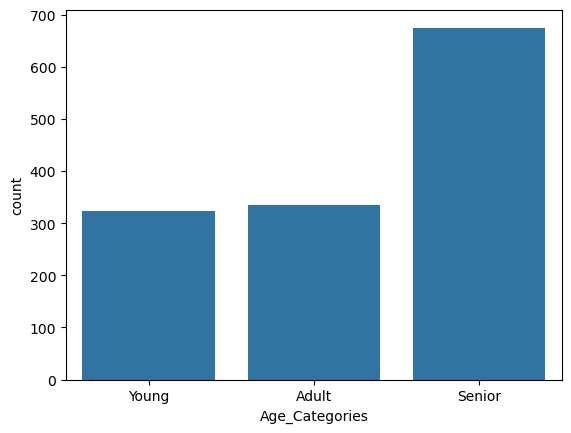

In [10]:
sns.countplot(data, x= 'Age_Categories')

### 3. Gender ke hisaab se total customers kitne hain?

In [11]:
gender = data.Gender.value_counts()
gender

Gender
Female    737
Male      626
Name: count, dtype: int64

<Axes: xlabel='Gender'>

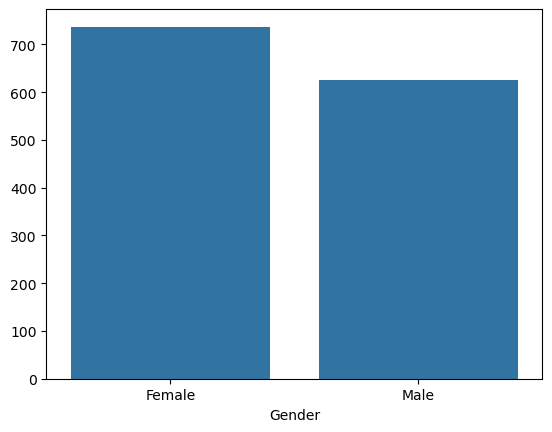

In [12]:
sns.barplot(x= gender.index, y= gender.values)

### 4. Har age category ki average rating calculate karein.

In [13]:
rating_avg = data.groupby('Age_Categories')['Rating'].mean()
rating_avg

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_11532\469639894.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_avg = data.groupby('Age_Categories')['Rating'].mean()


Age_Categories
Young     3.703704
Adult     3.722388
Senior    3.682963
Name: Rating, dtype: float64

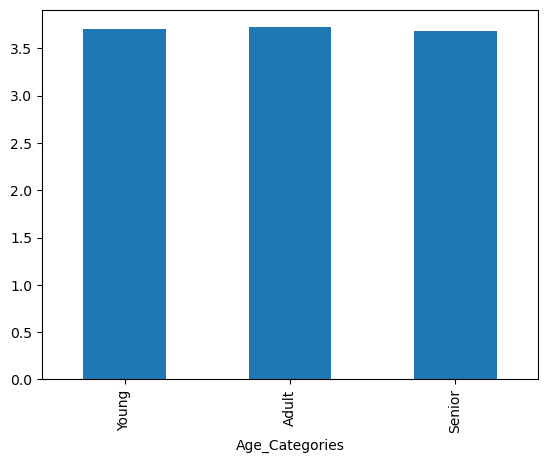

In [14]:
rating_avg.plot(kind='bar')
plt.show()

### 5. Har gender ki average purchase value calculate karein.

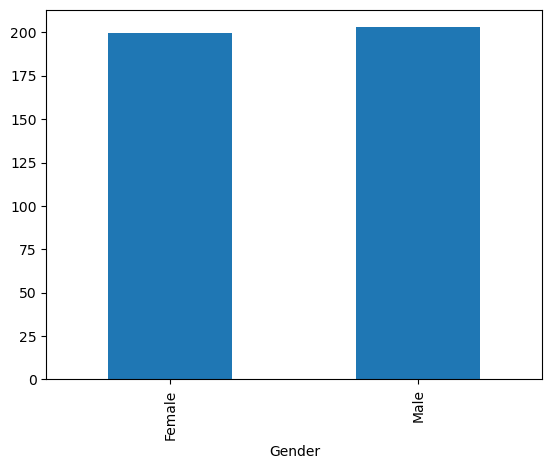

In [15]:
purchase_avg = data.groupby('Gender')['Price'].mean()
purchase_avg.plot(kind= 'bar')
plt.show()

### 6. Kis country mein sabse zyada customers hain?

In [16]:
data.Region.value_counts().index[0]

'Spain'

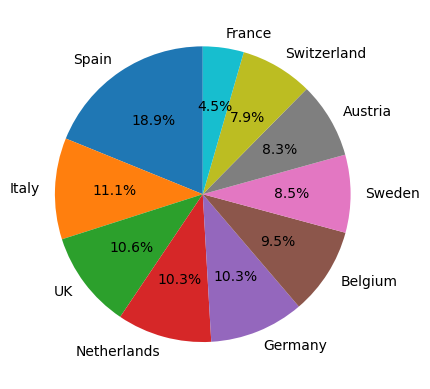

In [17]:
plt.pie(data.Region.value_counts(), labels= data.Region.value_counts().index, autopct= '%1.1f%%', startangle= 90)
plt.show()

### 7. Har country ki average review rating calculate karein.

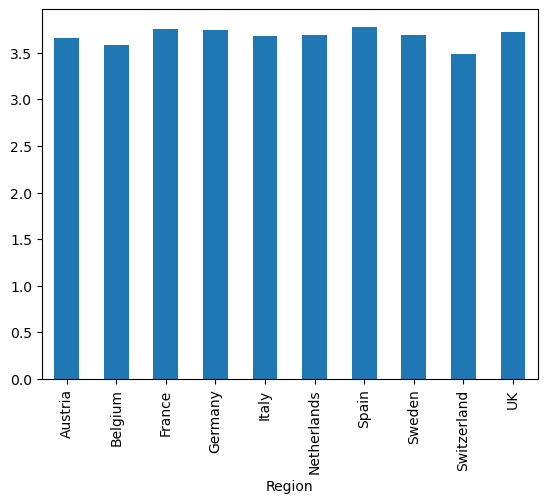

In [18]:
data.groupby('Region')['Rating'].mean().plot(kind='bar')
plt.show()

### 8. Har country ka average engagement score nikaalein.

### 9. Kis age group ki engagement sabse zyada hai?

### 10. Kya male aur female customers ki average ratings mein koi difference hai? Graph ke saath explain karein.

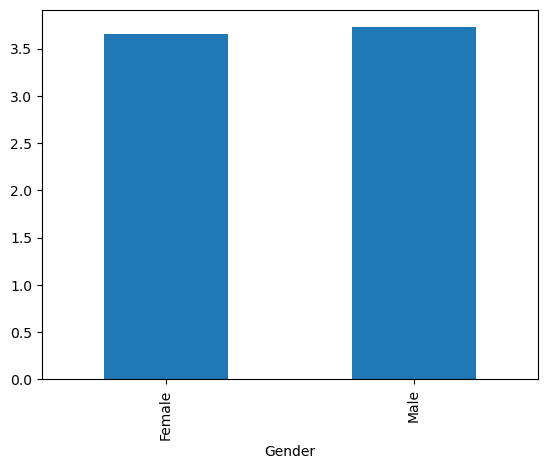

In [19]:
data.groupby('Gender')['Rating'].mean().plot(kind='bar')
plt.show()

#### Insight:
- Graph ko dekh kar yeh pata chalta hai ke Male aur Female customers ki average ratings mein koi bada ya khass farq nahi hai (dono ki average rating lagbhag barabar hai, jo ke $3.5$ ke paas hai).
- Iska matlab hai ke dono genders aapke products se ek jaisa hi satisfied hain.

In [20]:
data.head(2)

,ReviewID,CustomerID,ReviewDate,Rating,ReviewText,CustomerName,Gender,Age,Age_Category,Region,City,ProductName,Category,Price,Age_Categories
0,1,77,2023-12-23,3,"Average experience, nothing special.",David Lopez,Male,53,51-60,Spain,Madrid,Volleyball,Sports,42.80,Senior
1,2,80,2024-12-25,5,The quality is top-notch.,Laura Jones,Female,25,18-30,Netherlands,Amsterdam,Hockey Stick,Sports,173.83,Young


## Product Analysis

### 11. Sabse zyada purchase hone wale Top 10 products dikhayein.

In [21]:
data.ProductName.value_counts().sort_values().head(10)

ProductName
Cycling Helmet     56
Volleyball         59
Boxing Gloves      59
Running Shoes      63
Hockey Stick       63
Golf Clubs         64
Basketball         64
Football Helmet    64
Yoga Mat           65
Ski Boots          67
Name: count, dtype: int64

### 12. Sabse zyada reviews kis products ko mile hain?

In [22]:
data.groupby('ProductName')['ReviewText'].count().sort_values().head(1)

ProductName
Cycling Helmet    56
Name: ReviewText, dtype: int64

### 13. Sabse zyada engagement wale Top 10 products identify karein.

In [23]:
engagement_data['Total_Engagement'] = engagement_data['Views'] + engagement_data['Clicks'] + engagement_data['Likes']

In [24]:
engagement_data.head(2)

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,Views,Clicks,ProductName,Category,Total_Engagement
0,1,39,Blog,190,2023-08-30,1,9,1883.0,671.0,Baseball Glove,Sports,2744.0
1,2,48,Blog,114,2023-03-28,18,20,5280.0,532.0,Boxing Gloves,Sports,5926.0


In [25]:
engagement_data.groupby('ProductName')['Total_Engagement'].sum().sort_values().head(10)

ProductName
Fitness Tracker    609363.0
Surfboard          628303.0
Football Helmet    660221.0
Cycling Helmet     665989.0
Ski Boots          666459.0
Dumbbells          702875.0
Baseball Glove     708318.0
Volleyball         710476.0
Boxing Gloves      712971.0
Hockey Stick       722963.0
Name: Total_Engagement, dtype: float64

### 14. Har product category ki average rating calculate karein.

In [26]:
data.groupby('Category')['Rating'].mean()

Category
Sports    3.68672
Name: Rating, dtype: float64

### 15. Har category ki average engagement calculate karein.

In [27]:
engagement_data.groupby('Category')[['Likes', 'Views', 'Clicks', 'Total_Engagement']].mean()

,Likes,Views,Clicks,Total_Engagement
Category,,,,
Sports,114.368592,2545.607181,498.035691,3158.011464


### 16. Har category ki average views aur clicks compare karein.

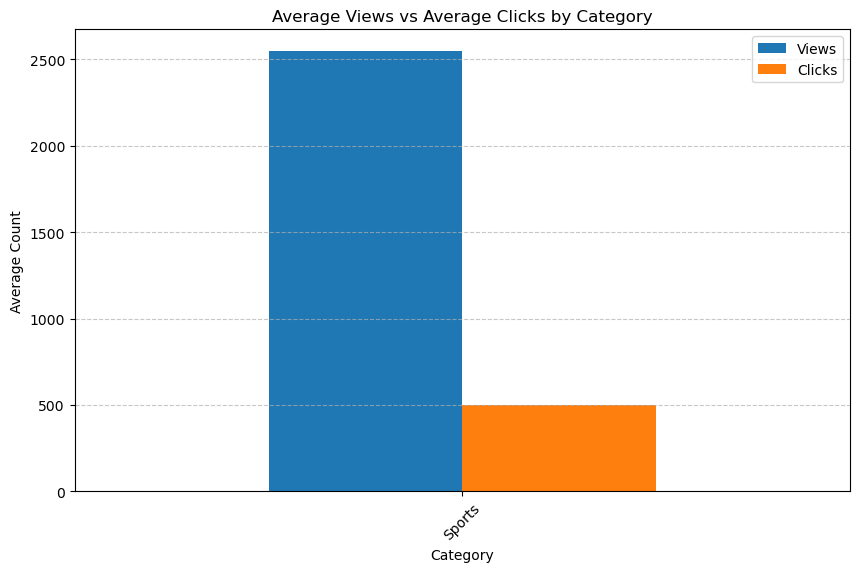

In [28]:
comparison_data = engagement_data.groupby('Category')[['Views', 'Clicks']].mean()

comparison_data.plot(kind='bar', figsize=(10, 6))
plt.title('Average Views vs Average Clicks by Category')
plt.ylabel('Average Count')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 17. Lowest rated Top 10 products kaun se hain?

In [29]:
data.groupby('ProductName')['Rating'].mean().sort_values().tail(10)

ProductName
Ice Skates         3.696203
Football Helmet    3.703125
Baseball Glove     3.726027
Ski Boots          3.731343
Fitness Tracker    3.776316
Basketball         3.781250
Kayak              3.786667
Cycling Helmet     3.803571
Swim Goggles       3.835616
Climbing Rope      3.913043
Name: Rating, dtype: float64

### 18. Highest rated Top 10 products kaun se hain?

In [30]:
data.groupby('ProductName')['Rating'].mean().sort_values().head(10)

ProductName
Golf Clubs       3.484375
Yoga Mat         3.523077
Tennis Racket    3.555556
Running Shoes    3.571429
Volleyball       3.576271
Boxing Gloves    3.610169
Dumbbells        3.626667
Surfboard        3.652778
Soccer Ball      3.666667
Hockey Stick     3.666667
Name: Rating, dtype: float64

### 19. Kis category mein views zyada hain lekin purchases kam hain?

### 20. Product popularity ko bar chart ke zariye visualize karein.

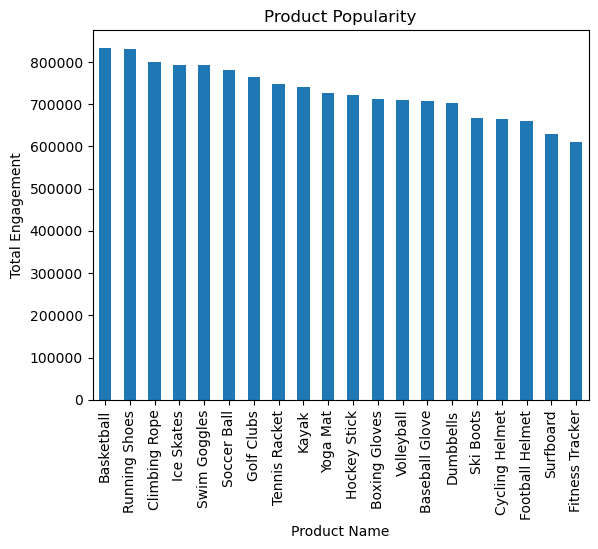

In [31]:
engagement_data.groupby('ProductName')['Total_Engagement'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Product Popularity')
plt.ylabel('Total Engagement')
plt.xlabel('Product Name')
plt.show()

## Engagement Analysis

### 21. Total Views, Total Clicks aur Total Likes calculate karein.

In [32]:
engagement_data[['Views', 'Likes', 'Clicks']].sum()

Views     11768342.0
Likes       528726.0
Clicks     2302419.0
dtype: float64

### 22. Overall Engagement Rate calculate karein.

In [33]:
print(f"Engagement Rate : {(((engagement_data['Likes'].sum()) + (engagement_data['Clicks']).sum())/(engagement_data['Views'].sum()) * 100).round()} %")

Engagement Rate : 24.0 %


### 23. Har product ka Engagement Rate compare karein.

In [34]:
product_engagement = engagement_data.groupby('ProductName')[['Views', 'Likes', 'Clicks']].sum().reset_index()
product_engagement.head(3)

,ProductName,Views,Likes,Clicks
0,Baseball Glove,566995.0,27452,113871.0
1,Basketball,676568.0,29583,127290.0
2,Boxing Gloves,571937.0,26512,114522.0


In [35]:
product_engagement['Engagement_Rate'] = ((product_engagement.Likes + product_engagement.Clicks) / (product_engagement.Views) * 100).round(2)
product_engagement.sort_values(by= 'Engagement_Rate', ascending= False, inplace= True)
product_engagement.head()

,ProductName,Views,Likes,Clicks,Engagement_Rate
15,Surfboard,498753.0,24622,104928.0,25.97
12,Running Shoes,660923.0,31106,139019.0,25.74
19,Yoga Mat,578549.0,29590,118852.0,25.66
14,Soccer Ball,623257.0,30009,127671.0,25.30
9,Hockey Stick,578316.0,27862,116785.0,25.01


In [36]:
engagement_data['Engagement_Rate'] = product_engagement.Engagement_Rate

### 24. Sabse zyada viewed aur sabse zyada clicked products identify karein.

In [37]:
engagement_data.sort_values(by= 'Views', ascending= False)[['ProductName', 'Views']].head(5)

,ProductName,Views
36,Running Shoes,9759.0
2893,Soccer Ball,9692.0
2155,Climbing Rope,9673.0
3762,Baseball Glove,9582.0
1188,Climbing Rope,9570.0


In [38]:
engagement_data.sort_values(by= 'Clicks', ascending= False)[['ProductName', 'Clicks']].head(5)

,ProductName,Clicks
401,Soccer Ball,4574.0
3647,Swim Goggles,4247.0
1421,Running Shoes,4238.0
610,Hockey Stick,4223.0
3460,Ice Skates,4168.0


### 25. Least engaged products kaun se hain?

In [39]:
product_engagement = engagement_data.groupby('ProductName')[['Views', 'Likes', 'Clicks']].sum().reset_index()
product_engagement['Engagement_Rate'] = ((product_engagement.Likes + product_engagement.Clicks) / (product_engagement.Views) * 100).round(2)
product_engagement.sort_values(by= 'Engagement_Rate', ascending= True, inplace= True)
product_engagement[['ProductName', 'Engagement_Rate']].head(5)

,ProductName,Engagement_Rate
6,Fitness Tracker,20.65
17,Tennis Racket,21.14
4,Cycling Helmet,22.74
18,Volleyball,22.92
13,Ski Boots,22.99


### 26. Daily ya Monthly conversion trend visualize karein.

In [40]:
engagement_data.head(2)

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,Views,Clicks,ProductName,Category,Total_Engagement,Engagement_Rate
0,1,39,Blog,190,2023-08-30,1,9,1883.0,671.0,Baseball Glove,Sports,2744.0,24.92
1,2,48,Blog,114,2023-03-28,18,20,5280.0,532.0,Boxing Gloves,Sports,5926.0,23.19


In [41]:
engagement_data['EngagementDate'] = pd.to_datetime(engagement_data['EngagementDate'])
monthly_data = engagement_data.set_index('EngagementDate').resample('M')[['Views']].mean()

C:\Users\Abdulah\AppData\Local\Temp\ipykernel_11532\1154569005.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = engagement_data.set_index('EngagementDate').resample('M')[['Views']].mean()


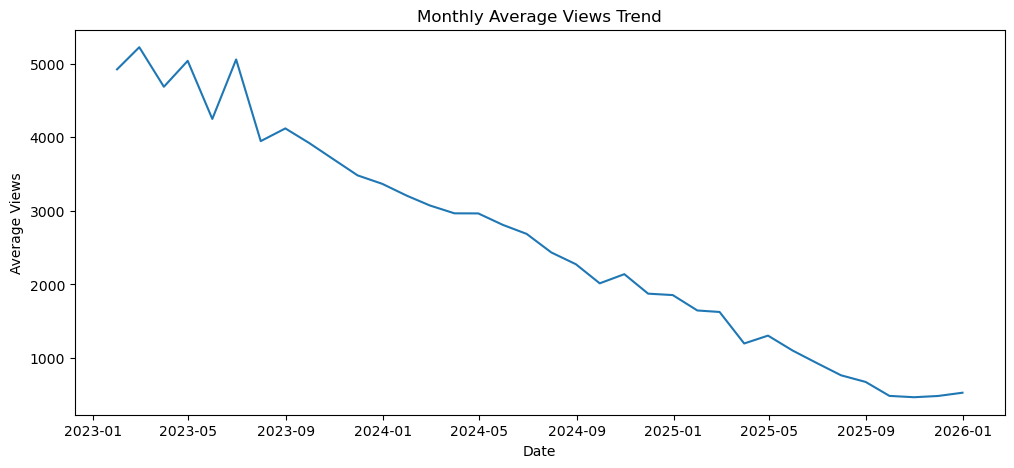

In [42]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_data, x=monthly_data.index, y='Views')
plt.title('Monthly Average Views Trend')
plt.xlabel('Date')
plt.ylabel('Average Views')
plt.show()

### 27. Agar Campaign ID available ho to har campaign ka CTR (Click Through Rate) calculate karein.

In [43]:
ctr = engagement_data.groupby('CompaignID')[['Clicks', 'Views']].sum().reset_index()

In [44]:
ctr["CTR_%"] = ((ctr.Clicks/ctr.Views)*100).round(2)

In [45]:
ctr = ctr.sort_values(by= 'CTR_%', ascending=False).reset_index().drop(columns=['index'])

In [46]:
ctr

,CompaignID,Clicks,Views,CTR_%
0,16,123208.0,574623.0,21.44
1,18,119826.0,567727.0,21.11
2,4,114733.0,552310.0,20.77
3,13,139068.0,670027.0,20.76
4,20,121701.0,597771.0,20.36
5,5,114533.0,566766.0,20.21
6,14,115233.0,576048.0,20.00
7,9,111544.0,563777.0,19.79
8,8,116030.0,589164.0,19.69
9,15,144703.0,735203.0,19.68


### 28. Top performing aur lowest performing campaigns identify karein.

In [47]:
print("Top Performing Campaigns:")
display(ctr.head(5))

print("\nLowest Performing Campaigns:")
display(ctr.tail(5))

Top Performing Campaigns:


,CompaignID,Clicks,Views,CTR_%
0,16,123208.0,574623.0,21.44
1,18,119826.0,567727.0,21.11
2,4,114733.0,552310.0,20.77
3,13,139068.0,670027.0,20.76
4,20,121701.0,597771.0,20.36



Lowest Performing Campaigns:


,CompaignID,Clicks,Views,CTR_%
15,17,118866.0,629203.0,18.89
16,11,107531.0,577691.0,18.61
17,19,125173.0,673675.0,18.58
18,12,97224.0,563147.0,17.26
19,1,85757.0,496751.0,17.26


## Combined Analysis

### 29. Merge kiye gaye datasets ki madad se yeh analyze karein ke kya engagement aur ratings ke darmiyan koi relationship hai? Scatter Plot aur Correlation ka use karein.

In [48]:
engagement_data.head(2)

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,Views,Clicks,ProductName,Category,Total_Engagement,Engagement_Rate
0,1,39,Blog,190,2023-08-30,1,9,1883.0,671.0,Baseball Glove,Sports,2744.0,24.92
1,2,48,Blog,114,2023-03-28,18,20,5280.0,532.0,Boxing Gloves,Sports,5926.0,23.19


In [49]:
data.head(2)

,ReviewID,CustomerID,ReviewDate,Rating,ReviewText,CustomerName,Gender,Age,Age_Category,Region,City,ProductName,Category,Price,Age_Categories
0,1,77,2023-12-23,3,"Average experience, nothing special.",David Lopez,Male,53,51-60,Spain,Madrid,Volleyball,Sports,42.80,Senior
1,2,80,2024-12-25,5,The quality is top-notch.,Laura Jones,Female,25,18-30,Netherlands,Amsterdam,Hockey Stick,Sports,173.83,Young


In [50]:
combined_data = pd.merge(engagement_data, data, how= 'inner', on= 'ProductName')
combined_data.head(2)

,EngagementID,ContentID,ContentType,Likes,EngagementDate,CompaignID,ProductID,Views,Clicks,ProductName,...,ReviewText,CustomerName,Gender,Age,Age_Category,Region,City,Category_y,Price,Age_Categories
0,1,39,Blog,190,2023-08-30,1,9,1883.0,671.0,Baseball Glove,...,"Great purchase, very satisfied.",Michael Gonzalez,Female,24,18-30,Italy,Rome,Sports,327.36,Young
1,1,39,Blog,190,2023-08-30,1,9,1883.0,671.0,Baseball Glove,...,"Good quality, but could be cheaper.",Emily Gonzalez,Female,38,31-40,Austria,Vienna,Sports,327.36,Adult


In [51]:
correlation = combined_data.Total_Engagement.corr(combined_data.Rating)
print(f"Correlation between Total Engagement and Rating: {correlation:.2f}")

Correlation between Total Engagement and Rating: 0.00


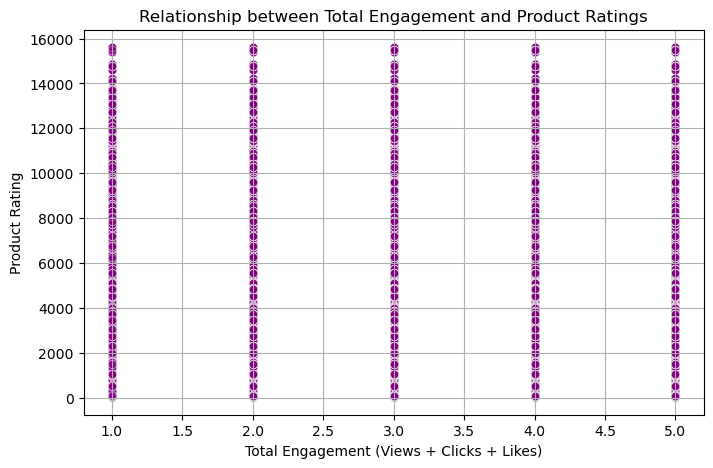

In [52]:
plt.figure(figsize=(8, 5))
sns.scatterplot(combined_data, x= 'Rating', y= 'Total_Engagement', alpha=0.5, color='purple')
plt.title('Relationship between Total Engagement and Product Ratings')
plt.xlabel('Total Engagement (Views + Clicks + Likes)')
plt.ylabel('Product Rating')
plt.grid(True)
plt.show()

### 30. Correlation Matrix (Heatmap) bana kar Views, Clicks, Likes, Rating, Duration aur Purchase ke darmiyan relationships identify karein aur apni business insights likhein.

In [63]:
matrix_data = engagement_data[['Views', 'Clicks', 'Likes']]
matrix_data.head()

,Views,Clicks,Likes
0,1883.0,671.0,190
1,5280.0,532.0,114
2,1905.0,204.0,32
3,2766.0,257.0,17
4,5116.0,1524.0,306


In [65]:
crr = matrix_data.corr(numeric_only=True)
crr

,Views,Clicks,Likes
Views,1.000000,0.848677,0.740195
Clicks,0.848677,1.000000,0.906630
Likes,0.740195,0.906630,1.000000


<Axes: >

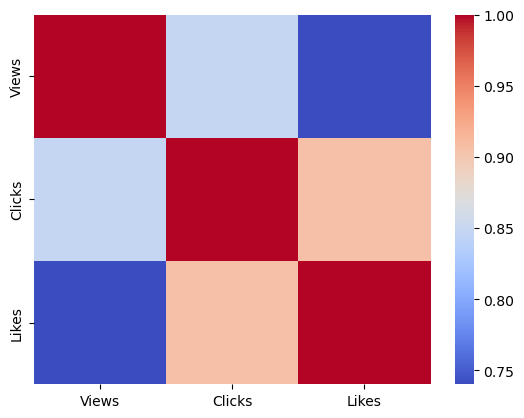

In [66]:
sns.heatmap(crr, cmap="coolwarm")